In [2]:
# Mission 6
# Load the Dataset

import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName#####=;AccountKey=######;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "Final_Mission_loan_data.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df_loan_data = pd.read_csv(StringIO(csv_content))

# Display the first few rows
display(df_loan_data.head(5))


StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 5, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 8c502264-cc02-4626-9a00-94b02eb76678)

In [3]:
# Missing values

# Check for missing values
missing_values = df_loan_data.isnull()

nulls = df_loan_data[missing_values.any(axis=1)]

#   Display the rows with null values
display(nulls)

# Identify Data Types
df_loan_data.dtypes

StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 6, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a631ad01-57b4-4960-9cf0-6ab27ea19f47)

person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

All items identified as type 'Object' above will need to be converted for the purposes of predictive analytics. 

## Exploratory Data Analysis

In [13]:
##Import Seaborn matplotlib
!pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt

# Get basic stats
print(df_loan_data.describe())



StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 118, Finished, Available, Finished, False)

         person_age  person_gender  person_education  person_income  \
count  45000.000000   45000.000000      45000.000000   4.500000e+04   
mean      27.764178       0.552022          1.743933   8.031905e+04   
std        6.045108       0.497292          1.479148   8.042250e+04   
min       20.000000       0.000000          0.000000   8.000000e+03   
25%       24.000000       0.000000          0.000000   4.720400e+04   
50%       26.000000       1.000000          1.000000   6.704800e+04   
75%       30.000000       1.000000          3.000000   9.578925e+04   
max      144.000000       1.000000          4.000000   7.200766e+06   

       person_emp_exp  person_home_ownership     loan_amnt   loan_intent  \
count    45000.000000           45000.000000  45000.000000  45000.000000   
mean         5.410333               1.696622   9583.157556      2.525911   
std          6.063532               1.440497   6314.886691      1.728305   
min          0.000000               0.000000    500.0000

- From the above we can see that the average age for a loan holder is approximately 28 years old and an average loan amount of $9,600 but ranging from $500 - $35000. 
- The average interest rate sits at 11% with some sitting as high as 20%. 
- AS a percentage of the loan holders income this sits at on average at 0.13 but ranges between 0 and 0.66. 
- The majority (75%) of loan holders have 8 years or less of credit history, but some have as much as 30 years recorded. 

StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 121, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


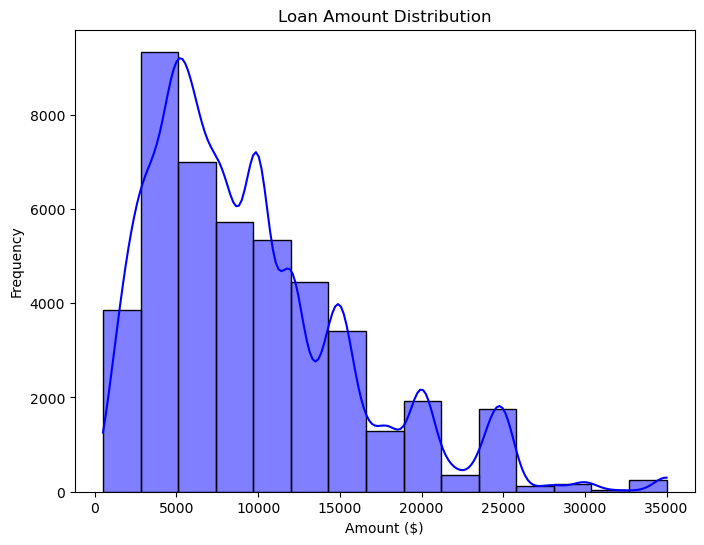

In [14]:

# Loan Amount distribution
plt.figure(figsize=(8, 6))
sns.histplot(df_loan_data['loan_amnt'], bins=15, kde=True, color='blue')
plt.title('Loan Amount Distribution')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.show()



The graph above shows that the vast majority of the loans sit under the $20,000 mark, with a large weighting towards lower value loans. This is positive for the bank as it means the risk they are exposed to is less than if they had a higher number of higher value loans. 

StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 127, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


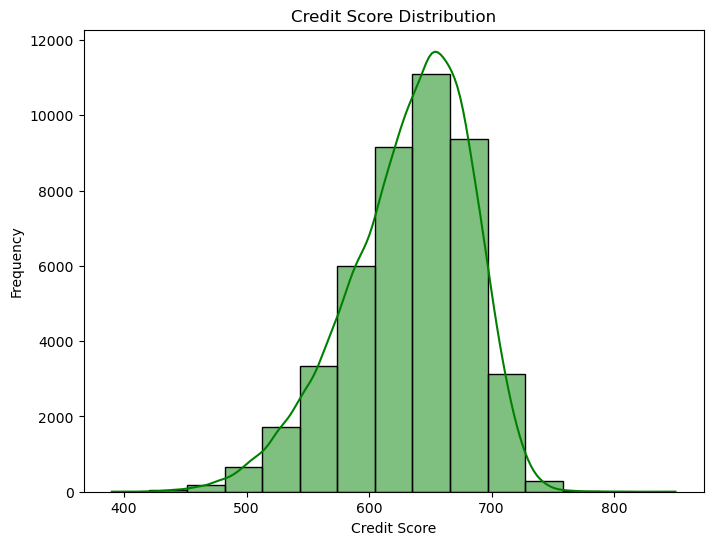

In [15]:
# Credit score distribution
plt.figure(figsize=(8, 6))
sns.histplot(df_loan_data['credit_score'], bins=15, kde=True, color='green')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()



The distribution curve shows that credit scores lean towards the higher end of the spectrum of credit scores, with the majority of the loan holders holding credit scores of 600-700. Depending on which model you use to rate credit scores, scores higher than 600 are generally seen to be reasonable, with anything above approximately 670 seen as 'Good' or 'Prime'. Only 25% of the loans are sitting in the sub-600s, so appears to be a fair distribution of risk for the bank.

StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 130, Finished, Available, Finished, False)

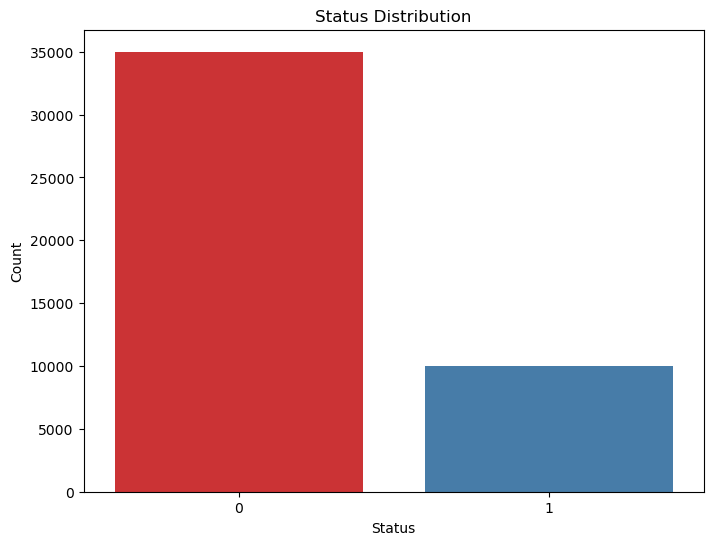

In [16]:
# Loan Status distribution (target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='loan_status', data=df_loan_data, palette='Set1')
plt.title('Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

The count above shows that around 10,000 of the 45,000 loans are currently in default. This means that around 22% of these loans are in default. This appears on the face of it to be quite a high number of loans in default and could be a cause for concern for ANZ. Further analysis will be done to understand any correlations between the status and the loan holders attributes and then predictive analytics applied to help inform better lending decisions in the future. 

StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 177, Finished, Available, Finished, False)

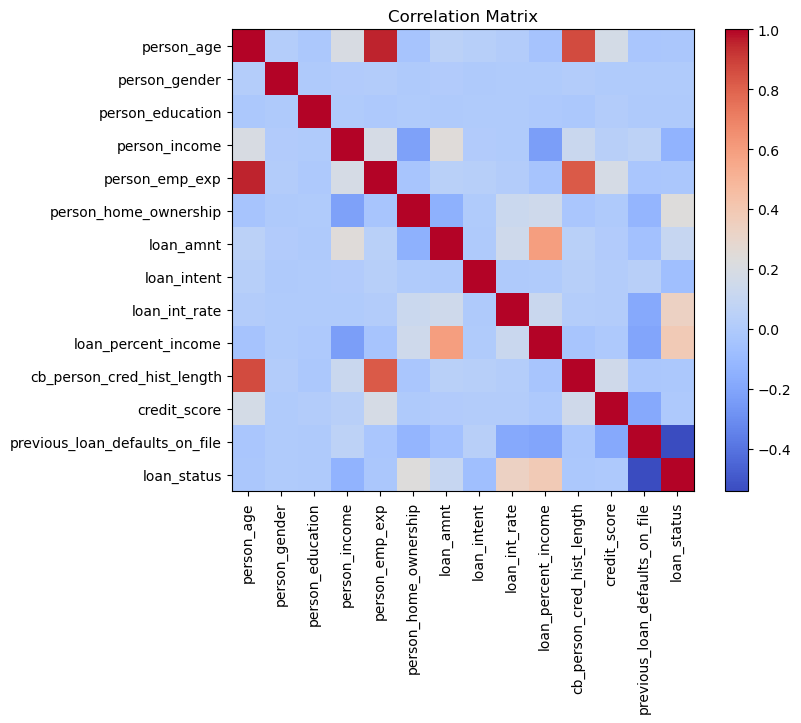

In [22]:
# Correlation matrix
# Select only numeric columns for correlation
numeric_df = df_loan_data.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Heatmap of correlations using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Title and labels
plt.title('Correlation Matrix')
plt.show()

## Predictive Modelling

In [6]:
#Predictive Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns 
label_encoder = LabelEncoder()
df_loan_data['person_gender'] = label_encoder.fit_transform(df_loan_data['person_gender'])
df_loan_data['person_education'] = label_encoder.fit_transform(df_loan_data['person_education'])
df_loan_data['person_home_ownership'] = label_encoder.fit_transform(df_loan_data['person_home_ownership'])
df_loan_data['loan_intent'] = label_encoder.fit_transform(df_loan_data['loan_intent'])
df_loan_data['previous_loan_defaults_on_file'] = label_encoder.fit_transform(df_loan_data['previous_loan_defaults_on_file'])

StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 9, Finished, Available, Finished, False)

In [7]:
# Features (X) and target (y)
X = df_loan_data[['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']]
y = df_loan_data['loan_status']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 11, Finished, Available, Finished, False)

In [12]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg_model = LogisticRegression()

# Train the model
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Create a table with Actual vs Predicted Status for Logistic Regression Model
results_df_log_reg = pd.DataFrame({
    'Actual Status': y_test,
    'Predicted Status (Logistic Regression)': y_pred_log_reg
})

# Display the table
print(results_df_log_reg.head())

StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 72, Finished, Available, Finished, False)

       Actual Status  Predicted Status (Logistic Regression)
37979              0                                       0
9911               0                                       0
43386              1                                       0
13822              0                                       0
44810              1                                       0


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
#rf_accuracy = accuracy_score(y_test, y_pred_rf)
#print(f"Random Forest Accuracy: {rf_accuracy}")

# Create a table with Actual vs Predicted Status for Random Forest
results_df_rf = pd.DataFrame({
    'Actual Status': y_test,
    'Predicted Status (Random Forest)': y_pred_rf
})

# Display the table
print(results_df_rf.head())


StatementMeta(, d4f017da-9347-4459-a2e9-72b2e1e26318, 55, Finished, Available, Finished, False)

       Actual Status  Predicted Status (Random Forest)
37979              0                                 0
9911               0                                 0
43386              1                                 1
13822              0                                 0
44810              1                                 1
